# 🔐 FaceLog — ArcFace trên VGGFace2 Subset
**Đồ án Trí Tuệ Nhân Tạo**

Pipeline:
1. Download **VGGFace2** dataset (top 500 người nhiều ảnh nhất ~50k ảnh)
2. ArcFace Loss (Additive Angular Margin)
3. Train ResNet-50 backbone từ đầu
4. Checkpoint tự động → tránh mất dữ liệu khi hết quota
5. Đánh giá ROC / AUC / FAR / FRR
6. Export weights cho app

> **Mục tiêu:** AUC ≥ 0.92  
> **Train time ước tính:** ~3-4h với T4 GPU  
> **Runtime:** GPU T4 (Runtime → Change runtime type → T4 GPU)

## 📦 Cell 1 — Cài thư viện

In [1]:
!pip install -q \
    torch torchvision \
    facenet-pytorch \
    scikit-learn \
    matplotlib \
    tqdm \
    Pillow \
    --quiet

print('✅ Cài xong thư viện')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 928.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 9.1 MB/s eta 0:00:00
✅ Cài xong thư viện


## 📥 Cell 2 — Download VGGFace2

In [2]:
import os
import subprocess

# ── Thử các path phổ biến khi add dataset qua Kaggle UI ──
POSSIBLE_PATHS = [
    '/kaggle/input/vggface2-dataset/vggface2/train',
    '/kaggle/input/vggface2-dataset/train',
    '/kaggle/input/vggface2/train',
    '/kaggle/input/vggface2/vggface2_train/train',
    '/kaggle/input/vgg-face2/data/train',
]

DATA_DIR = None
for p in POSSIBLE_PATHS:
    if os.path.exists(p):
        DATA_DIR = p
        break

if DATA_DIR is None:
    # Scan toàn bộ /kaggle/input để tìm folder chứa nhiều sub-folder (người)
    print("🔍 Đang scan /kaggle/input để tìm dataset...")
    for root, dirs, files in os.walk('/kaggle/input'):
        dirs.sort()
        if len(dirs) > 50:
            DATA_DIR = root
            print(f"   Tìm thấy: {root}  ({len(dirs)} folders)")
            break

if DATA_DIR is None:
    print("❌ Không tìm thấy dataset!")
    print("\n👉 Hướng dẫn thêm dataset vào Kaggle notebook:")
    print("   1. Bấm '+ Add Data' ở góc phải trên notebook")
    print("   2. Tìm kiếm: 'vggface2' hoặc 'VGGFace2'")
    print("   3. Dataset được dùng nhiều: 'VGGFace2 Dataset' của 'greatgrandpapaag'")
    print("   4. Sau khi add xong, chạy lại cell này")
    raise SystemExit("Vui lòng thêm dataset trước")
else:
    people_sample = os.listdir(DATA_DIR)[:5]
    print(f'✅ Dataset tìm thấy!')
    print(f'📁 DATA_DIR: {DATA_DIR}')
    print(f'👥 Ví dụ các folder người: {people_sample}')
    print(f'👤 Tổng số người: {len(os.listdir(DATA_DIR))}')

🔍 Đang scan /kaggle/input để tìm dataset...
   Tìm thấy: /kaggle/input/datasets/hearfool/vggface2/train  (480 folders)
✅ Dataset tìm thấy!
📁 DATA_DIR: /kaggle/input/datasets/hearfool/vggface2/train
👥 Ví dụ các folder người: ['n000232', 'n000213', 'n000208', 'n000340', 'n000137']
👤 Tổng số người: 480


## ⚙️ Cell 3 — Config toàn cục

In [3]:
import torch

# ───────────── HYPERPARAMETERS ─────────────
CFG = {
    # Data
    'data_dir'      : DATA_DIR,
    'max_people'    : 500,        # Top 500 người nhiều ảnh nhất
    'min_images'    : 10,         # Mỗi người tối thiểu 10 ảnh
    'img_size'      : 112,        # 112x112 — chuẩn cho ArcFace
    'val_ratio'     : 0.15,

    # Model
    'embedding_dim' : 512,
    'backbone'      : 'resnet50', # resnet50 hoặc resnet34

    # ArcFace margin
    'arcface_s'     : 64.0,       # scale
    'arcface_m'     : 0.50,       # margin (radian)

    # Training
    'epochs'        : 25,
    'batch_size'    : 128,        # Với T4 (16GB) dùng 128
    'momentum'      : 0.9,
    'weight_decay'  : 5e-4,
    'lr'            : 0.01,        # ← Giảm từ 0.1 xuống 0.01
    'lr_milestones' : [12, 18, 22],
    'lr_gamma'      : 0.1,
    'num_workers'   : 4,           # ← Thêm dòng này
    'warmup_epochs' : 3,           # ← Thêm warmup

    # Checkpoint
    'ckpt_dir'      : '/kaggle/working/checkpoints',
    'save_every'    : 2,          # Lưu checkpoint mỗi 2 epoch
    'output_weights': '/kaggle/working/arcface_vggface2.pth',
}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

os.makedirs(CFG['ckpt_dir'], exist_ok=True)
print('\n📋 Config:')
for k, v in CFG.items():
    print(f'   {k:20s}: {v}')

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB

📋 Config:
   data_dir            : /kaggle/input/datasets/hearfool/vggface2/train
   max_people          : 500
   min_images          : 10
   img_size            : 112
   val_ratio           : 0.15
   embedding_dim       : 512
   backbone            : resnet50
   arcface_s           : 64.0
   arcface_m           : 0.5
   epochs              : 25
   batch_size          : 128
   momentum            : 0.9
   weight_decay        : 0.0005
   lr                  : 0.01
   lr_milestones       : [12, 18, 22]
   lr_gamma            : 0.1
   num_workers         : 4
   warmup_epochs       : 3
   ckpt_dir            : /kaggle/working/checkpoints
   save_every          : 2
   output_weights      : /kaggle/working/arcface_vggface2.pth


## 🗃️ Cell 4 — Dataset: VGGFace2 Subset (top 500 người)

In [4]:
import os
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import numpy as np


class VGGFace2SubsetDataset(Dataset):
    """
    Load VGGFace2, chỉ lấy top `max_people` người có nhiều ảnh nhất.
    Mỗi người phải có ít nhất `min_images` ảnh.
    """
    def __init__(self, root, transform=None,
                 min_images=10, max_people=500):
        self.transform = transform
        self.samples   = []       # (path, label)
        self.label_map = {}       # folder_name -> int
        self.classes   = []       # list of folder names

        # Đếm số ảnh mỗi người
        people_counts = []
        for person in sorted(os.listdir(root)):
            person_dir = os.path.join(root, person)
            if not os.path.isdir(person_dir):
                continue
            imgs = [f for f in os.listdir(person_dir)
                    if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            if len(imgs) >= min_images:
                people_counts.append((person, len(imgs)))

        # Sắp xếp giảm dần → lấy top max_people
        people_counts.sort(key=lambda x: x[1], reverse=True)
        people_counts = people_counts[:max_people]

        label = 0
        for person, _ in people_counts:
            person_dir = os.path.join(root, person)
            imgs = [f for f in os.listdir(person_dir)
                    if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            self.label_map[person] = label
            self.classes.append(person)
            for img_file in imgs:
                self.samples.append(
                    (os.path.join(person_dir, img_file), label)
                )
            label += 1

        print(f'✅ Dataset: {label} người, {len(self.samples):,} ảnh  '
              f'(~{len(self.samples)//label} ảnh/người trung bình)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


# ─── Augmentation ───
train_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'] + 10, CFG['img_size'] + 10)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ─── Load dataset ───
full_dataset = VGGFace2SubsetDataset(
    root        = CFG['data_dir'],
    transform   = train_transform,
    min_images  = CFG['min_images'],
    max_people  = CFG['max_people'],
)

NUM_CLASSES = len(full_dataset.classes)
print(f'\n🏷️  Số classes: {NUM_CLASSES}')

# ─── Train / Val split ───
val_size   = int(len(full_dataset) * CFG['val_ratio'])
train_size = len(full_dataset) - val_size

train_set, val_set = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Dùng val_transform cho val_set
# (random_split giữ nguyên transform nên ta override thủ công)
class ValWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

val_set_final = ValWrapper(val_set, val_transform)

train_loader = DataLoader(train_set, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'],
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_set_final, batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'],
                          pin_memory=True)

print(f'\n📊 Train: {train_size:,} ảnh ({len(train_loader)} batch)')
print(f'   Val:   {val_size:,} ảnh ({len(val_loader)} batch)')

✅ Dataset: 480 người, 176,398 ảnh  (~367 ảnh/người trung bình)

🏷️  Số classes: 480

📊 Train: 149,939 ảnh (1171 batch)
   Val:   26,459 ảnh (207 batch)


## 🧠 Cell 5 — Model: ResNet-50 Backbone + ArcFace Head

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import math


# ────────────────────────────────────────────
# 1. ArcFace Loss
# ────────────────────────────────────────────
class ArcFaceLoss(nn.Module):
    """
    ArcFace: Additive Angular Margin Loss
    Paper: Deng et al., 2019 (https://arxiv.org/abs/1801.07698)

    s  = feature scale (default 64)
    m  = angular margin in radians (default 0.50 ≈ 28.6°)
    """
    def __init__(self, in_features, num_classes, s=64.0, m=0.50):
        super().__init__()
        self.s           = s
        self.m           = m
        self.num_classes = num_classes
        # Learnable weight matrix: (num_classes, embedding_dim)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

        # Pre-compute constants
        self.cos_m  = math.cos(m)
        self.sin_m  = math.sin(m)
        self.th     = math.cos(math.pi - m)   # cos(pi - m)
        self.mm     = math.sin(math.pi - m) * m  # sin(pi-m)*m

    def forward(self, embeddings, labels):
        # Normalize embeddings & weights → cosine similarity
        cos_theta = F.linear(
            F.normalize(embeddings),
            F.normalize(self.weight)
        )  # (B, num_classes)
        cos_theta = cos_theta.clamp(-1 + 1e-7, 1 - 1e-7)

        # Compute cos(theta + m) using angle addition formula
        sin_theta        = torch.sqrt(1.0 - cos_theta ** 2)
        cos_theta_plus_m = cos_theta * self.cos_m - sin_theta * self.sin_m

        # Heuristic: nếu theta > pi - m → dùng cos_theta - mm (tránh không đơn điệu)
        cos_theta_plus_m = torch.where(
            cos_theta > self.th,
            cos_theta_plus_m,
            cos_theta - self.mm
        )

        # One-hot mask cho ground truth class
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1.0)

        # Chỉ áp margin cho đúng class, còn lại giữ nguyên cos_theta
        logits = one_hot * cos_theta_plus_m + (1.0 - one_hot) * cos_theta
        logits = logits * self.s

        loss = F.cross_entropy(logits, labels)
        return loss, logits


# ────────────────────────────────────────────
# 2. ResNet Backbone (embedding extractor)
# ────────────────────────────────────────────
class FaceEmbedder(nn.Module):
    """
    ResNet-50 (hoặc 34) với head được thay bằng:
    FC → BN → (embedding)
    Không có activation ở cuối — ArcFace normalize sau.
    """
    def __init__(self, embedding_dim=512, backbone='resnet50'):
        super().__init__()
        if backbone == 'resnet50':
            base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            in_features = 2048
        else:  # resnet34
            base = models.resnet34(weights=None)
            in_features = 512

        # Giữ lại toàn bộ trừ avgpool và fc
        self.features = nn.Sequential(*list(base.children())[:-2])

        # Custom head
        self.gap  = nn.AdaptiveAvgPool2d(1)         # Global Average Pool
        self.bn1  = nn.BatchNorm2d(in_features)
        self.drop = nn.Dropout(0.4)
        self.fc   = nn.Linear(in_features, embedding_dim, bias=False)
        self.bn2  = nn.BatchNorm1d(embedding_dim)

        # Khởi tạo
        for m in [self.fc, self.bn2]:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)   # (B, C, H', W')
        x = self.bn1(x)
        x = self.gap(x)        # (B, C, 1, 1)
        x = x.view(x.size(0), -1)  # (B, C)
        x = self.drop(x)
        x = self.fc(x)         # (B, embedding_dim)
        x = self.bn2(x)
        return x


# ─── Khởi tạo model ───
model     = FaceEmbedder(CFG['embedding_dim'], CFG['backbone']).to(DEVICE)
arc_head  = ArcFaceLoss(CFG['embedding_dim'], NUM_CLASSES,
                         s=CFG['arcface_s'], m=CFG['arcface_m']).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'✅ Backbone: {CFG["backbone"]}')
print(f'   Parameters: {total_params:.1f}M')
print(f'   Embedding dim: {CFG["embedding_dim"]}')
print(f'   ArcFace classes: {NUM_CLASSES}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


✅ Backbone: resnet50
   Parameters: 24.6M
   Embedding dim: 512
   ArcFace classes: 480


## 🏋️ Cell 6 — Training với Auto-Checkpoint

In [6]:
import torch.optim as optim
from torch.optim.lr_scheduler import MultiStepLR
from tqdm import tqdm
import time
import json

# ─── Optimizer & Scheduler ───
params = list(model.parameters()) + list(arc_head.parameters())
optimizer = optim.SGD(params,
                      lr=CFG['lr'],
                      momentum=CFG['momentum'],
                      weight_decay=CFG['weight_decay'],
                      nesterov=True)
scheduler = MultiStepLR(optimizer,
                        milestones=CFG['lr_milestones'],
                        gamma=CFG['lr_gamma'])

# ─── Resume từ checkpoint nếu có ───
start_epoch = 0
history     = {'train_loss': [], 'val_loss': [], 'val_acc': []}

latest_ckpt = os.path.join(CFG['ckpt_dir'], 'latest.pth')
if os.path.exists(latest_ckpt):
    print(f'📂 Tìm thấy checkpoint: {latest_ckpt}')
    ckpt = torch.load(latest_ckpt, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    arc_head.load_state_dict(ckpt['arc_head'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt['epoch'] + 1
    history     = ckpt.get('history', history)
    print(f'   Resume từ epoch {start_epoch}')
else:
    print('🆕 Bắt đầu train từ đầu')


# ─── Hàm lưu checkpoint ───
def save_checkpoint(epoch, is_best=False):
    state = {
        'epoch'    : epoch,
        'model'    : model.state_dict(),
        'arc_head' : arc_head.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'history'  : history,
    }
    path = os.path.join(CFG['ckpt_dir'], 'latest.pth')
    torch.save(state, path)
    if is_best:
        best_path = os.path.join(CFG['ckpt_dir'], 'best.pth')
        torch.save(state, best_path)
        print(f'   ⭐ Best model lưu tại {best_path}')


# ─── Train 1 epoch ───
def train_epoch(epoch):
    model.train()
    arc_head.train()
    total_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{CFG["epochs"]} [Train]',
                leave=False, ncols=100)
    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        embeddings = model(imgs)
        loss, logits = arc_head(embeddings, labels)
        loss.backward()

        # Gradient clipping (ổn định training)
        torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

        pbar.set_postfix(loss=f'{loss.item():.4f}',
                         acc=f'{correct/total:.3f}')

    avg_loss = total_loss / total
    avg_acc  = correct / total
    elapsed  = time.time() - t0
    return avg_loss, avg_acc, elapsed


# ─── Validate ───
@torch.no_grad()
def validate():
    model.eval()
    arc_head.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(val_loader, desc='  Val', leave=False, ncols=100):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        embeddings = model(imgs)
        loss, logits = arc_head(embeddings, labels)

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

# Warmup scheduler
def get_lr(epoch):
    warmup = CFG.get('warmup_epochs', 3)
    if epoch < warmup:
        return CFG['lr'] * (epoch + 1) / warmup
    return CFG['lr']

# Thay MultiStepLR bằng:
from torch.optim.lr_scheduler import MultiStepLR, LambdaLR

warmup_epochs = CFG.get('warmup_epochs', 3)
warmup_scheduler = LambdaLR(optimizer,
    lr_lambda=lambda ep: (ep + 1) / warmup_epochs if ep < warmup_epochs else 1.0
)
main_scheduler = MultiStepLR(optimizer,
    milestones=CFG['lr_milestones'],
    gamma=CFG['lr_gamma']
)

# ─── Main training loop ───
best_val_acc = max([0.0] + history['val_acc']) if history['val_acc'] else 0.0
print(f'\n🚀 Bắt đầu training từ epoch {start_epoch+1}/{CFG["epochs"]}')
print(f'   Best val acc hiện tại: {best_val_acc:.4f}\n')

for epoch in range(start_epoch, CFG['epochs']):
    train_loss, train_acc, t = train_epoch(epoch)
    val_loss,   val_acc      = validate()
    if epoch < warmup_epochs:
        warmup_scheduler.step()
    else:
        main_scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc

    # In kết quả
    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:3d}/{CFG["epochs"]}  '
          f'| train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'| val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  '
          f'| lr={lr_now:.6f}  | {t:.0f}s  '
          f'{"⭐" if is_best else ""}')

    # Lưu checkpoint
    if (epoch + 1) % CFG['save_every'] == 0 or is_best:
        save_checkpoint(epoch, is_best)

print(f'\n✅ Training xong!  Best val acc: {best_val_acc:.4f}')

🆕 Bắt đầu train từ đầu

🚀 Bắt đầu training từ epoch 1/25
   Best val acc hiện tại: 0.0000



Epoch   1/25  | train_loss=34.3808  train_acc=0.0046  | val_loss=29.8703  val_acc=0.0392  | lr=0.006667  | 474s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth


Epoch   2/25  | train_loss=26.5096  train_acc=0.0864  | val_loss=22.0648  val_acc=0.2072  | lr=0.010000  | 485s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth


Epoch   3/25  | train_loss=20.2557  train_acc=0.2334  | val_loss=19.0417  val_acc=0.3411  | lr=0.010000  | 486s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth


Epoch   4/25  | train_loss=15.6522  train_acc=0.3793  | val_loss=16.4910  val_acc=0.4300  | lr=0.010000  | 486s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth


...

Epoch  21/25  | train_loss=1.3223  train_acc=0.9360  | val_loss=4.5135  val_acc=0.8606  | lr=0.000100  | 486s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth


Epoch  22/25  | train_loss=1.0828  train_acc=0.9460  | val_loss=4.2381  val_acc=0.8669  | lr=0.000100  | 484s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth


Epoch  23/25  | train_loss=0.9940  train_acc=0.9497  | val_loss=4.2273  val_acc=0.8676  | lr=0.000100  | 487s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth


Epoch  24/25  | train_loss=0.9395  train_acc=0.9521  | val_loss=4.1703  val_acc=0.8683  | lr=0.000100  | 489s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth


Epoch  25/25  | train_loss=0.9192  train_acc=0.9533  | val_loss=4.1662  val_acc=0.8691  | lr=0.000010  | 488s  ⭐
   ⭐ Best model lưu tại /kaggle/working/checkpoints/best.pth

✅ Training xong!  Best val acc: 0.8691


## 📊 Cell 7 — Vẽ Learning Curves

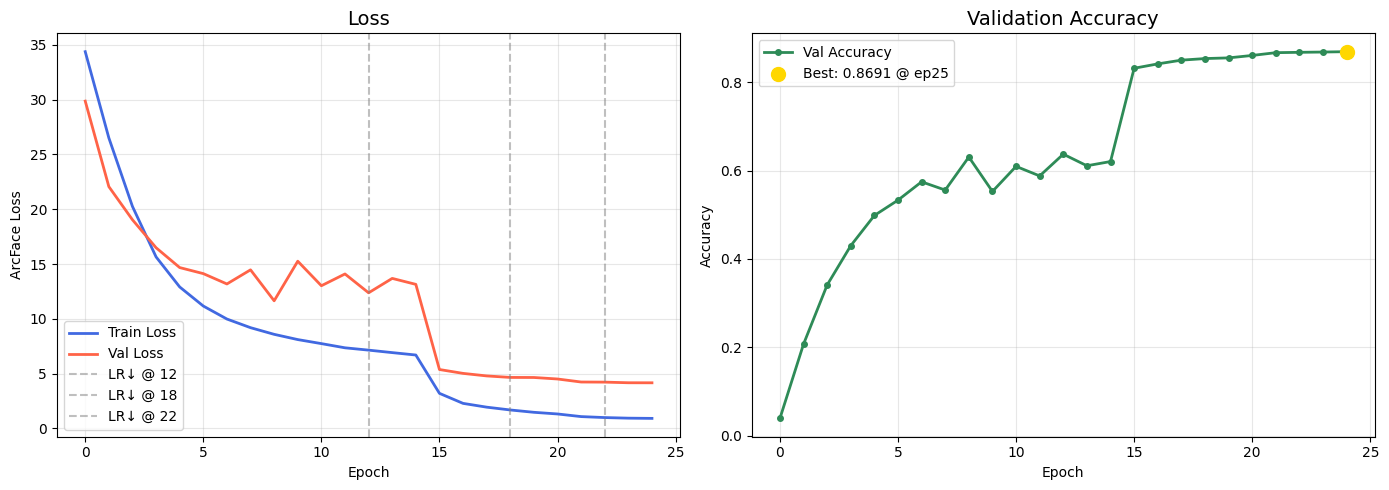

📈 Lưu tại /kaggle/working/training_curves.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
ax1.plot(history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
for m in CFG['lr_milestones']:
    if m < len(history['train_loss']):
        ax1.axvline(m, color='gray', linestyle='--', alpha=0.5, label=f'LR↓ @ {m}')
ax1.set_title('Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('ArcFace Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['val_acc'], label='Val Accuracy',
         color='seagreen', linewidth=2, marker='o', markersize=4)
best_ep  = int(np.argmax(history['val_acc']))
best_acc = max(history['val_acc'])
ax2.scatter(best_ep, best_acc, color='gold', s=100, zorder=5,
            label=f'Best: {best_acc:.4f} @ ep{best_ep+1}')
ax2.set_title('Validation Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Lưu tại /kaggle/working/training_curves.png')

## 🔬 Cell 8 — Đánh giá: ROC, AUC, FAR/FRR, EER

In [8]:
from sklearn.metrics import roc_curve, auc
from itertools import combinations
import random

# ─── Load best model ───
best_ckpt_path = os.path.join(CFG['ckpt_dir'], 'best.pth')
if os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    print(f'✅ Load best model (epoch {ckpt["epoch"]+1})')
else:
    print('ℹ️  Dùng model hiện tại (chưa có best.pth)')


# ─── Tạo embedding gallery ───
@torch.no_grad()
def build_gallery(loader, max_batches=None):
    model.eval()
    all_emb, all_lbl = [], []
    for i, (imgs, labels) in enumerate(tqdm(loader, desc='Building gallery', ncols=80)):
        if max_batches and i >= max_batches:
            break
        emb = model(imgs.to(DEVICE))
        emb = F.normalize(emb, dim=1)  # L2-normalize
        all_emb.append(emb.cpu())
        all_lbl.append(labels)
    return torch.cat(all_emb).numpy(), torch.cat(all_lbl).numpy()


print('\n⏳ Trích xuất embeddings từ val set...')
embeddings, labels = build_gallery(val_loader)
print(f'   Shape: {embeddings.shape}  ({len(np.unique(labels))} người)')


# ─── Tạo cặp same/different ngẫu nhiên ───
def generate_pairs(embeddings, labels, n_pairs=50000, seed=42):
    rng = np.random.default_rng(seed)
    unique_labels = np.unique(labels)

    # Nhóm indices theo label
    idx_by_label = {lb: np.where(labels == lb)[0] for lb in unique_labels}

    same_pairs, diff_pairs = [], []

    # Same-person pairs
    for lb in unique_labels:
        idxs = idx_by_label[lb]
        if len(idxs) >= 2:
            for i, j in combinations(idxs, 2):
                same_pairs.append((i, j, 1))

    # Different-person pairs
    all_labels_list = list(unique_labels)
    for _ in range(len(same_pairs)):  # Balanced
        lb1, lb2 = rng.choice(all_labels_list, 2, replace=False)
        i = rng.choice(idx_by_label[lb1])
        j = rng.choice(idx_by_label[lb2])
        diff_pairs.append((i, j, 0))

    all_pairs = same_pairs + diff_pairs
    rng.shuffle(all_pairs)
    return all_pairs[:n_pairs]


print('\n⏳ Tạo cặp ảnh...')
pairs = generate_pairs(embeddings, labels)
print(f'   Tổng: {len(pairs)} cặp  '
      f'(same={sum(p[2] for p in pairs):,}, '
      f'diff={sum(1-p[2] for p in pairs):,})')

# ─── Tính cosine similarity ───
print('\n⏳ Tính cosine similarity...')
scores, y_true = [], []
for i, j, is_same in pairs:
    cos_sim = float(np.dot(embeddings[i], embeddings[j]))
    scores.append(cos_sim)
    y_true.append(is_same)

scores = np.array(scores)
y_true = np.array(y_true)


# ─── ROC / AUC ───
fpr, tpr, thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

# EER (Equal Error Rate)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2
eer_th  = thresholds[eer_idx]

# FAR/FRR tại threshold EER
y_pred_eer = (scores >= eer_th).astype(int)
far = np.sum((y_pred_eer == 1) & (y_true == 0)) / np.sum(y_true == 0)
frr = np.sum((y_pred_eer == 0) & (y_true == 1)) / np.sum(y_true == 1)

print(f'\n📊 Kết quả đánh giá:')
print(f'   AUC   : {roc_auc:.4f}')
print(f'   EER   : {eer:.4f}  (threshold={eer_th:.4f})')
print(f'   FAR   : {far:.4f}')
print(f'   FRR   : {frr:.4f}')
print(f'   Val Accuracy (classification): {max(history["val_acc"]):.4f}')

✅ Load best model (epoch 25)

⏳ Trích xuất embeddings từ val set...


Building gallery: 100%|███████████████████████| 207/207 [00:27<00:00,  7.56it/s]


   Shape: (26459, 512)  (480 người)

⏳ Tạo cặp ảnh...
   Tổng: 50000 cặp  (same=25,040, diff=24,960)

⏳ Tính cosine similarity...

📊 Kết quả đánh giá:
   AUC   : 0.9911
   EER   : 0.0343  (threshold=0.1411)
   FAR   : 0.0343
   FRR   : 0.0343
   Val Accuracy (classification): 0.8691


## 📉 Cell 9 — Vẽ ROC Curve + FAR/FRR

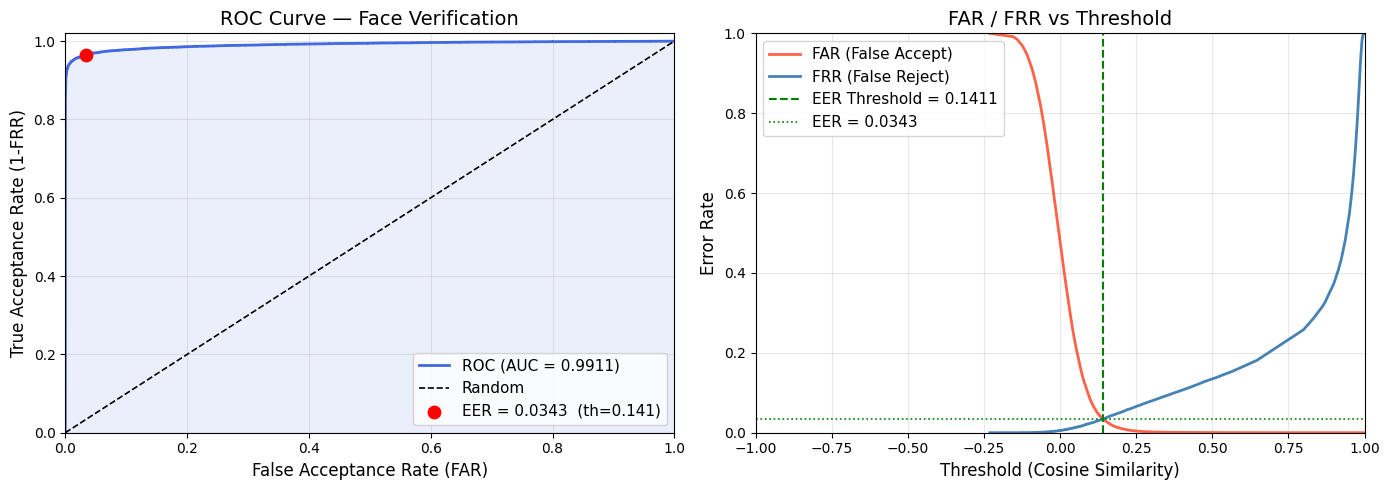

📈 Lưu tại /kaggle/working/roc_far_frr.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── ROC Curve ───
ax = axes[0]
ax.plot(fpr, tpr, color='royalblue', lw=2,
        label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random')
ax.scatter(fpr[eer_idx], tpr[eer_idx], color='red', s=80, zorder=5,
           label=f'EER = {eer:.4f}  (th={eer_th:.3f})')
ax.fill_between(fpr, tpr, alpha=0.1, color='royalblue')
ax.set_xlabel('False Acceptance Rate (FAR)', fontsize=12)
ax.set_ylabel('True Acceptance Rate (1-FRR)', fontsize=12)
ax.set_title('ROC Curve — Face Verification', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# ─── FAR / FRR vs Threshold ───
ax2 = axes[1]
fnr_arr = 1 - tpr
# Lọc thresholds trong khoảng hợp lý
mask = (thresholds >= -1) & (thresholds <= 1)
ax2.plot(thresholds[mask], fpr[mask], label='FAR (False Accept)',
         color='tomato',   lw=2)
ax2.plot(thresholds[mask], fnr_arr[mask], label='FRR (False Reject)',
         color='steelblue', lw=2)
ax2.axvline(eer_th, color='green', linestyle='--', lw=1.5,
            label=f'EER Threshold = {eer_th:.4f}')
ax2.axhline(eer,    color='green', linestyle=':',  lw=1.2,
            label=f'EER = {eer:.4f}')
ax2.set_xlabel('Threshold (Cosine Similarity)', fontsize=12)
ax2.set_ylabel('Error Rate', fontsize=12)
ax2.set_title('FAR / FRR vs Threshold', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_xlim([-1, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('/kaggle/working/roc_far_frr.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Lưu tại /kaggle/working/roc_far_frr.png')

## 🔭 Cell 10 — t-SNE Embedding Visualization


⏳ Chạy t-SNE trên 599 samples...


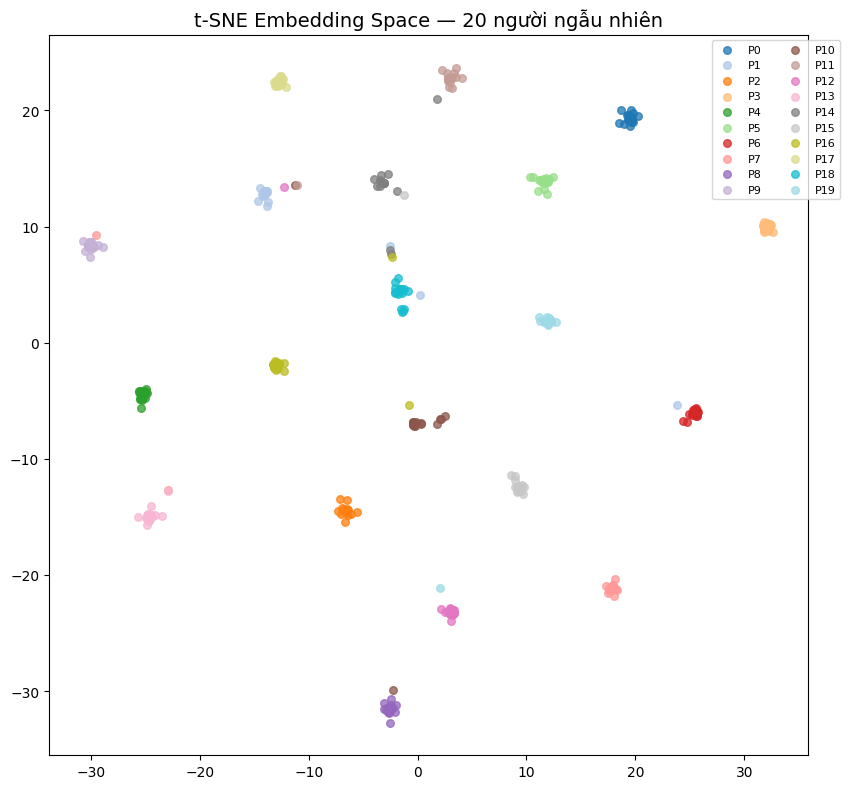

📈 Lưu tại /kaggle/working/tsne.png


In [10]:
from sklearn.manifold import TSNE

# Lấy 20 người ngẫu nhiên, tối đa 30 ảnh/người
N_PEOPLE_VIS  = 20
N_IMGS_PERSON = 30

unique_labels = np.unique(labels)
chosen_labels = np.random.choice(unique_labels, min(N_PEOPLE_VIS, len(unique_labels)), replace=False)

emb_vis, lbl_vis = [], []
for lb in chosen_labels:
    mask = labels == lb
    idxs = np.where(mask)[0][:N_IMGS_PERSON]
    emb_vis.append(embeddings[idxs])
    lbl_vis.append(np.full(len(idxs), lb))

emb_vis = np.vstack(emb_vis)
lbl_vis = np.concatenate(lbl_vis)

# Map label về 0..N_PEOPLE_VIS-1
label_remap = {lb: i for i, lb in enumerate(np.unique(lbl_vis))}
lbl_vis_mapped = np.array([label_remap[l] for l in lbl_vis])

print(f'\n⏳ Chạy t-SNE trên {len(emb_vis)} samples...')
tsne  = TSNE(n_components=2, random_state=42,
             perplexity=min(30, len(emb_vis) - 1))
emb2d = tsne.fit_transform(emb_vis)

plt.figure(figsize=(10, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(np.unique(lbl_vis_mapped))))
for i, lb in enumerate(np.unique(lbl_vis_mapped)):
    m = lbl_vis_mapped == lb
    plt.scatter(emb2d[m, 0], emb2d[m, 1], c=[colors[i]],
                alpha=0.75, s=30, label=f'P{lb}')
plt.title('t-SNE Embedding Space — 20 người ngẫu nhiên', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('📈 Lưu tại /kaggle/working/tsne.png')

## 💾 Cell 11 — Export weights cho app

In [11]:
import json

# ─── Load best checkpoint ───
best_ckpt_path = os.path.join(CFG['ckpt_dir'], 'best.pth')
if os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    best_epoch = ckpt['epoch'] + 1
else:
    best_epoch = CFG['epochs']
    print('⚠️  Không tìm thấy best.pth, dùng model hiện tại')

# ─── Export chỉ backbone weights ───
torch.save({
    'model_state_dict'  : model.state_dict(),
    'embedding_dim'     : CFG['embedding_dim'],
    'backbone'          : CFG['backbone'],
    'num_classes'       : NUM_CLASSES,
    'img_size'          : CFG['img_size'],
    'best_epoch'        : best_epoch,
    'auc'               : float(roc_auc),
    'eer'               : float(eer),
    'eer_threshold'     : float(eer_th),
    'label_map'         : full_dataset.label_map,
}, CFG['output_weights'])

print(f'✅ Đã lưu weights: {CFG["output_weights"]}')
print(f'   Best epoch  : {best_epoch}')
print(f'   AUC         : {roc_auc:.4f}')
print(f'   EER         : {eer:.4f}')
print(f'   EER threshold: {eer_th:.4f}')
print(f'\n→ Download file này và copy vào thư mục models/ của app.')

# ─── Lưu metadata JSON riêng ───
meta = {
    'backbone'      : CFG['backbone'],
    'embedding_dim' : CFG['embedding_dim'],
    'num_classes'   : NUM_CLASSES,
    'img_size'      : CFG['img_size'],
    'best_epoch'    : best_epoch,
    'auc'           : round(float(roc_auc), 4),
    'eer'           : round(float(eer), 4),
    'eer_threshold' : round(float(eer_th), 4),
}
with open('/kaggle/working/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('\n📄 Metadata lưu tại /kaggle/working/model_meta.json')
print(json.dumps(meta, indent=2))

✅ Đã lưu weights: /kaggle/working/arcface_vggface2.pth
   Best epoch  : 25
   AUC         : 0.9911
   EER         : 0.0343
   EER threshold: 0.1411

→ Download file này và copy vào thư mục models/ của app.

📄 Metadata lưu tại /kaggle/working/model_meta.json
{
  "backbone": "resnet50",
  "embedding_dim": 512,
  "num_classes": 480,
  "img_size": 112,
  "best_epoch": 25,
  "auc": 0.9911,
  "eer": 0.0343,
  "eer_threshold": 0.1411
}


## 📋 Cell 12 — Tóm tắt kết quả

In [12]:
print('=' * 55)
print('         KẾT QUẢ CUỐI CÙNG — FaceLog ArcFace')
print('=' * 55)
print(f'  Dataset       : VGGFace2 top {CFG["max_people"]} người')
print(f'  Tổng ảnh train: {train_size:,}')
print(f'  Backbone      : {CFG["backbone"].upper()}')
print(f'  Embedding dim : {CFG["embedding_dim"]}')
print(f'  ArcFace (s,m) : ({CFG["arcface_s"]}, {CFG["arcface_m"]})')
print(f'  Epochs        : {best_epoch}/{CFG["epochs"]}')
print('-' * 55)
print(f'  Val Accuracy  : {max(history["val_acc"]):.4f}')
print(f'  AUC           : {roc_auc:.4f}')
print(f'  EER           : {eer:.4f}  (threshold={eer_th:.4f})')
print(f'  FAR @ EER     : {far:.4f}')
print(f'  FRR @ EER     : {frr:.4f}')
print('=' * 55)
print(f'  Weights       : arcface_vggface2.pth')
print(f'  Metadata      : model_meta.json')
print('=' * 55)

         KẾT QUẢ CUỐI CÙNG — FaceLog ArcFace
  Dataset       : VGGFace2 top 500 người
  Tổng ảnh train: 149,939
  Backbone      : RESNET50
  Embedding dim : 512
  ArcFace (s,m) : (64.0, 0.5)
  Epochs        : 25/25
-------------------------------------------------------
  Val Accuracy  : 0.8691
  AUC           : 0.9911
  EER           : 0.0343  (threshold=0.1411)
  FAR @ EER     : 0.0343
  FRR @ EER     : 0.0343
  Weights       : arcface_vggface2.pth
  Metadata      : model_meta.json
